**PSMDSSC 103** Assignment 2 Polynomial Regression
Levi P. Caaya III
MEng CpE 1 - 2nd Semester AY 2025 - 2026

# Polynomial Regression Using Standard Scaling

## Import Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.linear_model import LinearRegression


## Load the dataset

In [2]:
# fetch dataset
url = "https://raw.githubusercontent.com/levi3612/traffic_volume_dataset/refs/heads/main/Metro_Interstate_Traffic_Volume.csv"

In [3]:
df = pd.read_csv(url)
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


## Do the EDA (Exploratory Data Analysis)

In [4]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [5]:
df.shape

(48204, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


## Get meaningful features from date_time column

In [7]:
df["date_time"] = pd.to_datetime(df["date_time"])
#formatting to a python datetime format

In [12]:
df["hour"] = df["date_time"].dt.hour
df["day"] = df["date_time"].dt.day
df["day_of_week"] = df["date_time"].dt.dayofweek
df["month"] = df["date_time"].dt.month

Look for possible relationship for traffic volume

<function matplotlib.pyplot.show(close=None, block=None)>

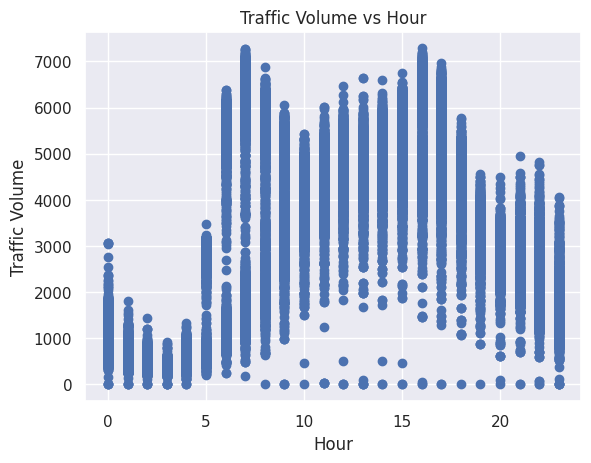

In [13]:
#arbitrarilly check if there is a relationship between time of the day and traffic volume

x_hour = df['hour']
y_hour = df['traffic_volume']

plt.scatter(x_hour,y_hour)
plt.xlabel('Hour')
plt.ylabel('Traffic Volume')
plt.title('Traffic Volume vs Hour')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

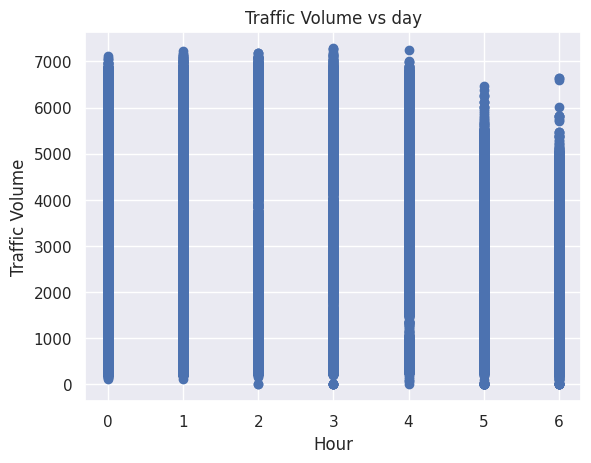

In [14]:
#arbitrarilly check if there is a relationship between day of the week and traffic volume

x_day = df['day_of_week']
y_day = df['traffic_volume']

plt.scatter(x_day,y_day)
plt.xlabel('Hour')
plt.ylabel('Traffic Volume')
plt.title('Traffic Volume vs day')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

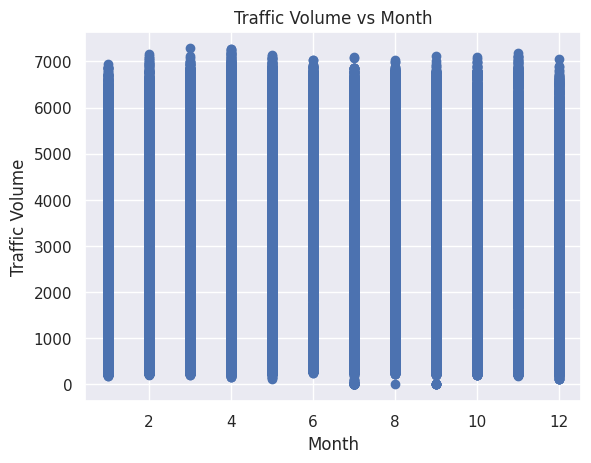

In [15]:
#arbitrarilly check if there is a relationship month and traffic volume

x_month = df['month']
y_month = df['traffic_volume']

plt.scatter(x_month,y_month)
plt.xlabel('Month')
plt.ylabel('Traffic Volume')
plt.title('Traffic Volume vs Month')
plt.show

## Data Preparation

In [16]:
X = df.drop(['traffic_volume', 'date_time'], axis = 1)
X

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,hour,day,day_of_week,month
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,9,2,1,10
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,10,2,1,10
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,11,2,1,10
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,12,2,1,10
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,13,2,1,10
...,...,...,...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,19,30,6,9
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,20,30,6,9
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,21,30,6,9
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,22,30,6,9


### Get dummies for categorical data

In [17]:
X_dummies = pd.get_dummies(X, drop_first=True)
X_dummies

,temp,rain_1h,snow_1h,clouds_all,hour,day,day_of_week,month,holiday_Columbus Day,holiday_Independence Day,...,weather_description_sleet,weather_description_smoke,weather_description_snow,weather_description_thunderstorm,weather_description_thunderstorm with drizzle,weather_description_thunderstorm with heavy rain,weather_description_thunderstorm with light drizzle,weather_description_thunderstorm with light rain,weather_description_thunderstorm with rain,weather_description_very heavy rain
0,288.28,0.0,0.0,40,9,2,1,10,False,False,...,False,False,False,False,False,False,False,False,False,False
1,289.36,0.0,0.0,75,10,2,1,10,False,False,...,False,False,False,False,False,False,False,False,False,False
2,289.58,0.0,0.0,90,11,2,1,10,False,False,...,False,False,False,False,False,False,False,False,False,False
3,290.13,0.0,0.0,90,12,2,1,10,False,False,...,False,False,False,False,False,False,False,False,False,False
4,291.14,0.0,0.0,75,13,2,1,10,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48199,283.45,0.0,0.0,75,19,30,6,9,False,False,...,False,False,False,False,False,False,False,False,False,False
48200,282.76,0.0,0.0,90,20,30,6,9,False,False,...,False,False,False,False,False,False,False,False,False,False
48201,282.73,0.0,0.0,90,21,30,6,9,False,False,...,False,False,False,False,False,False,False,False,False,False
48202,282.09,0.0,0.0,90,22,30,6,9,False,False,...,False,False,False,False,False,False,False,False,False,False


In [18]:
X = X_dummies

In [19]:
y = df['traffic_volume']

## Model Evaluation with Different Degrees

I used a pipeline to generate, scale, and evaluate models in different degrees (1- 4)




---






In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [22]:
model_deg1 = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=1)),
    ("lr", LinearRegression())
])

model_deg1.fit(X_train, y_train)
y_pred_1 = model_deg1.predict(X_test)

rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred_1))
mae_1 = mean_absolute_error(y_test, y_pred_1)
r2_1 = r2_score(y_test, y_pred_1)

print("Degree 1 → RMSE:", rmse_1, "MAE:", mae_1, "R²:", r2_1)

Degree 1 → RMSE: 1806.3370887982217 MAE: 1580.9485374918868 R²: 0.17469520981582665


In [23]:
model_deg2 = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2)),
    ("lr", LinearRegression())
])

model_deg2.fit(X_train, y_train)
y_pred_2 = model_deg2.predict(X_test)

rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))
mae_2 = mean_absolute_error(y_test, y_pred_2)
r2_2 = r2_score(y_test, y_pred_2)

print("Degree 2 → RMSE:", rmse_2, "MAE:", mae_2, "R²:", r2_2)


Degree 2 → RMSE: 1076.3013446459784 MAE: 834.8908654558967 R²: 0.7069885894723289


**Due to Memory constraint, I cannot run degree 3 and 4 and will proceed with analyzing Degree 1 and 2**

In [20]:


model_deg3 = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3)),
    ("lr", LinearRegression())
])

model_deg3.fit(X_train, y_train)
y_pred_3 = model_deg3.predict(X_test)

rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred_3))
mae_3 = mean_absolute_error(y_test, y_pred_3)
r2_3 = r2_score(y_test, y_pred_3)

print("Degree 3 → RMSE:", rmse_3, "MAE:", mae_3, "R²:", r2_3)


KeyboardInterrupt: 

In [ ]:
model_deg4 = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=4)),
    ("lr", LinearRegression())
])

model_deg4.fit(X_train, y_train)
y_pred_4 = model_deg4.predict(X_test)

rmse_4 = np.sqrt(mean_squared_error(y_test, y_pred_4))
mae_4 = mean_absolute_error(y_test, y_pred_4)
r2_4 = r2_score(y_test, y_pred_4)

print("Degree 4 → RMSE:", rmse_4, "MAE:", mae_4, "R²:", r2_4)


## Visualization

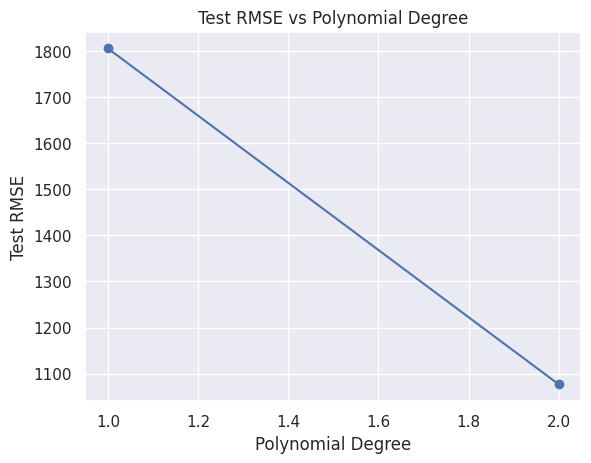

In [24]:
#RMSE

degrees = [1, 2]
rmse_values = [rmse_1, rmse_2]

plt.figure()
plt.plot(degrees, rmse_values, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("Test RMSE")
plt.title("Test RMSE vs Polynomial Degree")
plt.show()

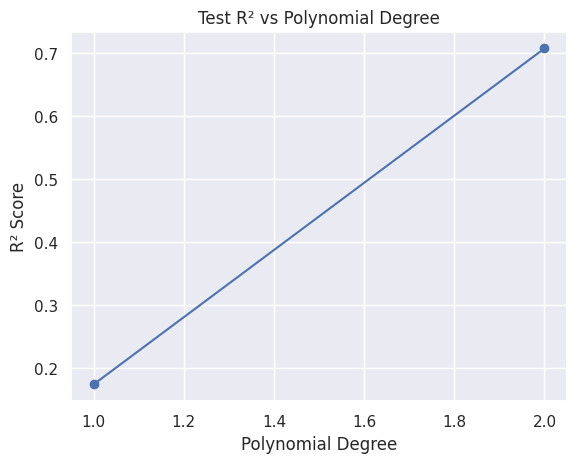

In [25]:
r2_values = [r2_1, r2_2]

plt.figure()
plt.plot(degrees, r2_values, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title("Test R² vs Polynomial Degree")
plt.show()


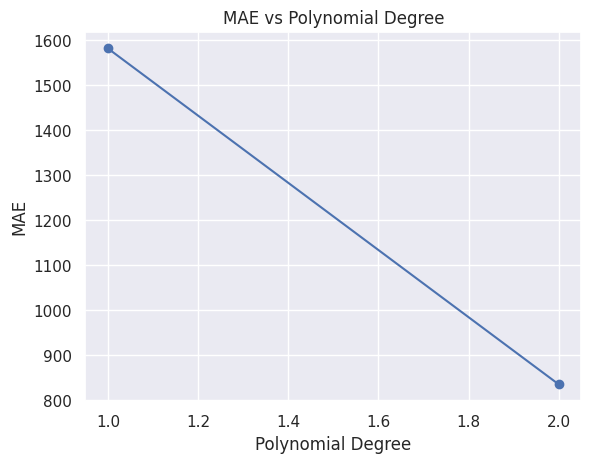

In [26]:
mae_values = [mae_1, mae_2]

plt.figure()
plt.plot(degrees, mae_values, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("MAE")
plt.title("MAE vs Polynomial Degree")
plt.show()

## Predicted vs Actual

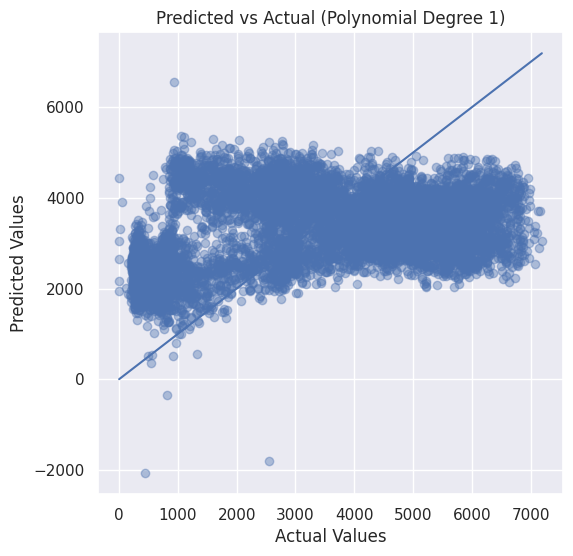

In [29]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_1, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual (Polynomial Degree 1)")
plt.show()


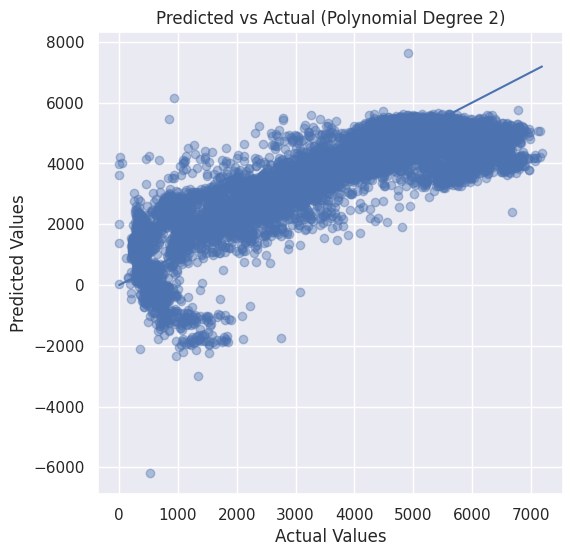

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_2, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual (Polynomial Degree 2)")
plt.show()
